# Ocean acidification indicators on the North American margins — virtual Icechunk

Builds one [Icechunk](https://icechunk.io) store from **NCEI accession
[0270962](https://www.ncei.noaa.gov/data/oceans/ncei/ocads/metadata/0270962.html)**, the
coastal climatology of ocean acidification indicators from the surface to 500 m on the
North American ocean margins (Jiang et al., DOI
[10.25921/g8pb-zy76](https://doi.org/10.25921/g8pb-zy76)).

The archive is **twelve NetCDF-4 files, one indicator each**, all on the same
`(14 depth, 76 lat, 141 lon)` 1° grid. This notebook merges them into a single store of
**72 variables** using [VirtualiZarr](https://virtualizarr.readthedocs.io): the store holds
Zarr metadata and byte-range references, and **no array data is copied** — every read goes
back to the files at NCEI.

Destination: `https://data.source.coop/ocean-icechunks/oa-indicators/climatology`

## What this notebook does

1. Opens each of the twelve files virtually and merges them on the shared grid.
2. Promotes the real coordinate values to index coordinates (the source ships phony,
   all-zero HDF5 dimension scales — see section 4).
3. Rewrites the metadata to **CF-1.12 and ACDD-1.3**. Metadata only; no data value changes.
4. Writes and commits the store.
5. Validates the **published** store from the anonymous read path and compares all 72
   arrays against the source files.

## Running it

Both write flags default to `False`, so the notebook runs end to end **with no credentials
and writes nothing**: it builds the virtual dataset and the metadata, skips the write, then
validates the live published store. Set `RUN_WRITE = True` (with Source Cooperative write
credentials) to rebuild.

Python 3.12 or newer is required — `icechunk` 2.x is published `requires_python = ">=3.12"`.

In [1]:
# Dependencies. In the git repo: pip install -r requirements.txt
# Standalone (downloaded on its own from Source Cooperative), uncomment:
# !pip install -q "icechunk>=2.2" "virtualizarr>=2.7" xarray zarr obspec-utils obstore \
#     h5netcdf h5py fsspec aiohttp "dask[array]" numpy boto3 matplotlib
#
# icechunk 2.x requires Python >= 3.12. Unlike the CoastWatch notebooks in this
# repository, there is no NetCDF-3 path here, so kerchunk and scipy are NOT needed.

In [2]:
import sys
# icechunk_utils.py lives at the repo root (one level up) in the git repo, or
# alongside this notebook when downloaded from Source Cooperative. Jupyter puts
# the notebook's own directory on sys.path, so a co-located copy imports as is;
# the '..' entry below covers the nested git-repo layout.
sys.path.insert(0, '..')

import datetime
import re
import time
from pathlib import Path

import fsspec
import h5py
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from obstore.store import HTTPStore
from obspec_utils.registry import ObjectStoreRegistry
from virtualizarr import open_virtual_dataset
from virtualizarr.parsers import HDFParser

print('icechunk', icechunk.__version__, '| xarray', xr.__version__, '| python', sys.version.split()[0])

icechunk 2.2.2 | xarray 2026.7.0 | python 3.12.12


## 1. Configuration

`RUN_WRITE` and `RUN_MIRROR` are both `False` in the committed copy, so re-running this
notebook changes nothing. `WRITE_TO_TEST` decides which repository a write goes to; leave
it `True` until a change has been proved on the scratch repo.

In [3]:
# ------------------------------------------------------------------ source
NCEI = 'https://www.ncei.noaa.gov'
SRC = NCEI + '/data/oceans/ncei/ocads/data/0270962/'
# NCEI serves this archive to any user agent (checked 2026-09-17: curl, urllib
# and requests defaults all get 206 on a range request), unlike CoastWatch.
# A descriptive one is still polite.
UA = 'Mozilla/5.0 (compatible; fish-pace/icechunks oa-indicators build)'

# ------------------------------------------------------------- destination
SC_BUCKET = 'ocean-icechunks'
PROD_PREFIX = 'oa-indicators/climatology'      # the published store
TEST_PREFIX = 'test-repo/oa-indicators'        # source.coop/ocean-icechunks/test-repo
DOCS_PREFIX = 'oa-indicators'                  # where the docs are mirrored

# ------------------------------------------------------------------- flags
RUN_WRITE = False        # True (+ write credentials) to build or rebuild the store
WRITE_TO_TEST = True     # when RUN_WRITE: write to the scratch repo, not production
OVERWRITE = False        # when RUN_WRITE: replace a store that already holds data
RUN_MIRROR = False       # True to upload README / requirements / this notebook

DEST_PREFIX = TEST_PREFIX if WRITE_TO_TEST else PROD_PREFIX
# The store the validation sections read. With RUN_WRITE off — the committed
# default — that is the published production store.
CHECK_URL = f'https://data.source.coop/{SC_BUCKET}/' + (DEST_PREFIX if RUN_WRITE else PROD_PREFIX)

print('write:    ', f'{SC_BUCKET}/{DEST_PREFIX}'
      + (' (overwriting)' if OVERWRITE else '') if RUN_WRITE else 'disabled (RUN_WRITE=False)')
print('validate: ', CHECK_URL)

write:     disabled (RUN_WRITE=False)
validate:  https://data.source.coop/ocean-icechunks/oa-indicators/climatology


## 2. The source archive

Twelve NetCDF-4 (HDF5) files, one per indicator, each about 6.9 MB. Every file holds six
fields for its indicator on the same grid:

| Suffix | Field |
|---|---|
| `_an` | objectively analysed mean — **the field NCEI recommends using** |
| `_mn` | statistical mean of the observations in each grid square |
| `_sd` | standard deviation about that mean |
| `_SE` | standard error of the analysed field |
| `_dd` | number of observations |
| `_gp` | number of grid squares within the radius of influence |

The `INDICATORS` table below also carries the units and CF standard names applied in
section 5. `units` there are UDUNITS strings: the source writes `"N/A"` for every
dimensionless field and `"degrees Celsius"` — with a space, which UDUNITS will not parse —
for temperature. `standard_name` is filled in only where the
[CF standard name table](https://cfconventions.org/Data/cf-standard-names/current/build/cf-standard-name-table.html)
actually has an entry; it has none for saturation states, the Revelle factor, hydrogen ion
content, or carbonate per unit mass.

In [4]:
# (file stem, variable prefix, label, UDUNITS units, CF standard_name or None)
INDICATORS = [
    ('Aragonite',      'OmegaA', 'aragonite saturation state',               '1',         None),
    ('Calcite',        'OmegaC', 'calcite saturation state',                 '1',         None),
    ('Carbonate',      'CO3',    'carbonate ion content',                    'umol kg-1', None),
    ('DIC',            'DIC',    'total dissolved inorganic carbon content', 'umol kg-1',
     'moles_of_dissolved_inorganic_carbon_per_unit_mass_in_sea_water'),
    ('Hydrogen_free',  'Hfree',  'free hydrogen ion content',                'nmol kg-1', None),
    ('Hydrogen_total', 'Htotal', 'total hydrogen ion content',               'nmol kg-1', None),
    ('RF',             'RF',     'Revelle factor',                           '1',         None),
    ('Salinity',       'S',      'salinity (PSS-78)',                        '1',
     'sea_water_practical_salinity'),
    ('TA',             'TA',     'total alkalinity content',                 'umol kg-1',
     'sea_water_alkalinity_per_unit_mass_expressed_as_mole_equivalent'),
    ('Temperature',    'T',      'water temperature (ITS-90)',               'degree_Celsius',
     'sea_water_temperature'),
    ('fCO2',           'fCO2',   'fugacity of carbon dioxide',               'uatm',
     'fugacity_of_carbon_dioxide_in_sea_water'),
    ('pH',             'pHT',    'pH on the total scale',                    '1',
     'sea_water_ph_reported_on_total_scale'),
]

SUFFIXES = ('an', 'mn', 'sd', 'SE', 'dd', 'gp')
COORD_VARS = ['depth', 'latitude', 'longitude']   # loaded into memory, not referenced

print(f'{len(INDICATORS)} files x {len(SUFFIXES)} fields = '
      f'{len(INDICATORS) * len(SUFFIXES)} variables\n')

fs = fsspec.filesystem('http', client_kwargs={'headers': {'User-Agent': UA}})
total = 0
for stem, prefix, label, units, std in INDICATORS:
    size = fs.info(SRC + stem + '.nc')['size']
    total += size
    print(f'  {stem + ".nc":18s} {size / 1e6:6.1f} MB   {prefix + "_*":10s} {label}')
print(f'\n  {"total":18s} {total / 1e6:6.1f} MB of source files, none of which is copied')

12 files x 6 fields = 72 variables



  Aragonite.nc          7.2 MB   OmegaA_*   aragonite saturation state
  Calcite.nc            7.2 MB   OmegaC_*   calcite saturation state
  Carbonate.nc          7.2 MB   CO3_*      carbonate ion content


  DIC.nc                7.2 MB   DIC_*      total dissolved inorganic carbon content
  Hydrogen_free.nc      7.2 MB   Hfree_*    free hydrogen ion content
  Hydrogen_total.nc     7.2 MB   Htotal_*   total hydrogen ion content


  RF.nc                 7.2 MB   RF_*       Revelle factor
  Salinity.nc           7.2 MB   S_*        salinity (PSS-78)
  TA.nc                 7.2 MB   TA_*       total alkalinity content


  Temperature.nc        7.2 MB   T_*        water temperature (ITS-90)
  fCO2.nc               7.2 MB   fCO2_*     fugacity of carbon dioxide


  pH.nc                 7.2 MB   pHT_*      pH on the total scale

  total                86.7 MB of source files, none of which is copied


## 3. Open the twelve files virtually and merge

One `open_virtual_dataset` per file. The three coordinate variables are named in
`loadable_variables`, so they are read into memory as real arrays; everything else becomes
a `ManifestArray` — a reference to a byte range in the source file.

The grid is byte-identical in all twelve files (verified before this build), so the
coordinates are kept from the first file and dropped from the rest, and the merge is
`join='exact'`.

**`combine_attrs='drop_conflicts'`, not `'drop'`.** `xr.merge` applies `combine_attrs` to
*variable* attributes as well as to the dataset's, so `'drop'` silently empties every
variable's attrs — including the source descriptions kept as `comment` in section 5. The
per-file global attributes (each file's own `Title`, `Abstract`, `Citation`) are cleared
explicitly instead, and a single global set is written in section 5.

In [5]:
registry = ObjectStoreRegistry({NCEI: HTTPStore(NCEI, client_options={'user_agent': UA})})
parser = HDFParser()          # the source is NetCDF-4/HDF5, so no NetCDF-3 path is needed

t0 = time.perf_counter()
parts = []
for i, (stem, *_rest) in enumerate(INDICATORS):
    vds = open_virtual_dataset(
        url=SRC + stem + '.nc', parser=parser, registry=registry,
        loadable_variables=COORD_VARS, decode_times=False,
    )
    if i:                                   # identical grid in all twelve files
        vds = vds.drop_vars(COORD_VARS)
    vds.attrs = {}                          # per-file Title/Abstract/Citation
    parts.append(vds)

merged = xr.merge(parts, join='exact', combine_attrs='drop_conflicts')
print(f'opened and merged {len(parts)} files in {time.perf_counter() - t0:.1f}s')
print(f'{len(merged.data_vars)} variables (72 fields + 3 coordinates, still plain '
      f'variables at this point), dims {dict(merged.sizes)}')

# One chunk per array: the source arrays are contiguous and uncompressed, so each
# variable is a single 1.2 MB byte range covering the whole array. Nothing about that
# can be changed without rewriting the data, and at this size nothing needs to be.
example = merged['OmegaA_an'].data
print('\nOmegaA_an: shape', example.shape, 'in chunks of', example.metadata.chunks)
print('  reference ->', example.manifest.dict()['0.0.0'])

opened and merged 12 files in 11.6s
75 variables (72 fields + 3 coordinates, still plain variables at this point), dims {'lon': 141, 'lat': 76, 'dep': 14}

OmegaA_an: shape (14, 76, 141) in chunks of (14, 76, 141)
  reference -> {'path': 'https://www.ncei.noaa.gov/data/oceans/ncei/ocads/data/0270962/Aragonite.nc', 'offset': 15799, 'length': 1200192}


## 4. Promote the coordinates

The source files carry **phony HDF5 dimension scales** `dep`, `lat` and `lon` — arrays of
zeros marked `"This is a netCDF dimension but not a netCDF variable"` — while the real
coordinate values sit in three separate variables `depth`, `latitude` and `longitude`.
xarray hides the phony scales and reports `Dimensions without coordinates`, so as delivered
the data has no usable index coordinate at all: `sel(lat=...)` does not work.

`swap_dims` promotes the real variables to index coordinates, and `rename` gives them the
short conventional names. This is a metadata operation; the values are the source's own.

In [6]:
ds = merged.swap_dims({'dep': 'depth', 'lat': 'latitude', 'lon': 'longitude'})
ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})

print('coordinates:', list(ds.coords))
print('  depth', ds.depth.values)
print('  lat  ', ds.lat.values[:3], '...', ds.lat.values[-3:])
print('  lon  ', ds.lon.values[:3], '...', ds.lon.values[-3:])

coordinates: ['lon', 'lat', 'depth']
  depth [  0.  10.  20.  30.  50.  75. 100. 125. 150. 200. 250. 300. 400. 500.]
  lat   [10.5 11.5 12.5] ... [83.5 84.5 85.5]
  lon   [-179.5 -178.5 -177.5] ... [-41.5 -40.5 -39.5]


## 5. CF-1.12 and ACDD-1.3 metadata

Everything in this section is **metadata only — no array value is touched**, which is the
only kind of change a virtual store can make.

The source metadata needs three fixes to be CF-valid:

- **`units` is `"N/A"`** on every dimensionless field, and `"degrees Celsius"` (with a
  space) on temperature. Neither parses as UDUNITS. They become `"1"` and
  `"degree_Celsius"`.
- **`standard_name` holds free text**, not a CF standard name — `"Aragonite saturation
  state"`, `"Number_of_observations for pH on Total Scale"`. That text moves to
  `long_name`, and a real `standard_name` is supplied only where the CF table has one.
- **There are no global attributes** beyond a per-file title, abstract and citation.

The source's own descriptive `long_name` is kept verbatim as `comment` (its line wrapping
squashed), and each variable gets a `source` attribute naming the file it references.

In [7]:
# suffix -> (long_name template, 'field' or 'count' units, standard_name rule, cell_methods)
SUFFIX_CF = {
    'an': ('Objectively analysed mean {label}',       'field', 'own', None),
    'mn': ('Statistical mean {label}',                'field', 'own', 'area: mean'),
    'sd': ('Standard deviation of {label}',           'field', 'own', 'area: standard_deviation'),
    'SE': ('Standard error of the analysed {label}',  'field', None,  None),
    'dd': ('Number of observations of {label}',       'count', 'number_of_observations', None),
    'gp': ('Number of grid squares within the radius of influence for {label}',
                                                      'count', None,  None),
}

CITATION = (
    'Jiang, Li-Qing; Boyer, Tim P.; Paver, Christopher R.; Reagan, James R.; Alin, Simone R.; '
    'Barbero, Leticia; Carter, Brendan R.; Feely, Richard A.; Wanninkhof, Rik (2022). '
    'Climatological distribution of ocean acidification indicators from surface to 500 meters '
    'water depth on the North American ocean margins from 2003-12-06 to 2018-11-22 '
    '(NCEI Accession 0270962). NOAA National Centers for Environmental Information. Dataset. '
    'https://doi.org/10.25921/g8pb-zy76.'
)


def squash(text):
    # The source wraps long_name across several indented lines.
    return re.sub(r'\s+', ' ', str(text)).strip()


def apply_cf(ds, built_utc=None):
    # Metadata only: no array value is touched.
    ds = ds.copy()
    built_utc = built_utc or datetime.datetime.now(datetime.timezone.utc).isoformat(
        timespec='seconds')

    ds['lat'].attrs = {'standard_name': 'latitude', 'long_name': 'Latitude',
                       'units': 'degrees_north', 'axis': 'Y'}
    ds['lon'].attrs = {'standard_name': 'longitude', 'long_name': 'Longitude',
                       'units': 'degrees_east', 'axis': 'X'}
    ds['depth'].attrs = {'standard_name': 'depth', 'long_name': 'Depth below sea surface',
                         'units': 'm', 'positive': 'down', 'axis': 'Z'}

    for stem, prefix, label, units, std in INDICATORS:
        for suffix, (template, unit_rule, std_rule, cell_methods) in SUFFIX_CF.items():
            name = f'{prefix}_{suffix}'
            if name not in ds:
                continue
            source_text = squash(ds[name].attrs.get('long_name', ''))
            attrs = {'long_name': template.format(label=label),
                     'units': units if unit_rule == 'field' else '1'}
            sname = std if std_rule == 'own' else std_rule
            if sname:
                attrs['standard_name'] = sname
            if cell_methods:
                attrs['cell_methods'] = cell_methods
            if source_text:
                attrs['comment'] = source_text
            attrs['source'] = SRC + stem + '.nc'
            ds[name].attrs = attrs

    ds.attrs = {
        'Conventions': 'CF-1.12, ACDD-1.3',
        'title': ('Climatological distribution of ocean acidification indicators from the '
                  'surface to 500 m on the North American ocean margins'),
        'summary': (
            '1x1 degree coastal climatologies of twelve ocean acidification and hydrographic '
            'indicators at 14 standard depth levels from the surface to 500 m on the North '
            'American ocean margins, gridded with the World Ocean Atlas objective-analysis '
            'technique from CODAP-NA and GLODAPv2 (2021) observations collected 2003-12-06 to '
            '2018-11-22 and adjusted to the year 2010. Each indicator has six fields: the '
            'objectively analysed mean (_an, the recommended field), the statistical mean '
            '(_mn), standard deviation (_sd), standard error (_SE), number of observations '
            '(_dd) and number of contributing grid squares (_gp).'),
        'keywords': ('ocean acidification, pH, aragonite saturation state, calcite saturation '
                     'state, dissolved inorganic carbon, total alkalinity, fugacity of carbon '
                     'dioxide, Revelle factor, climatology, North American ocean margins'),
        'source': ('NCEI Accession 0270962: twelve NetCDF-4 files, one per indicator, '
                   'objectively analysed from CODAP-NA (Version 2021) and GLODAPv2.2021'),
        'history': (f'{built_utc}: merged the twelve per-indicator NetCDF files of NCEI '
                    'accession 0270962 into a single virtual Icechunk store with VirtualiZarr '
                    '(byte-range references; no array data copied); promoted depth/latitude/'
                    'longitude to index coordinates named depth/lat/lon; rewrote variable and '
                    'global attributes to CF-1.12 and ACDD-1.3'),
        'institution': 'NOAA National Centers for Environmental Information (NCEI)',
        'creator_name': ('Li-Qing Jiang; Tim P. Boyer; Christopher R. Paver; Hyelim Yoo; '
                         'James R. Reagan; Simone R. Alin; Leticia Barbero; Brendan R. Carter; '
                         'Richard A. Feely; Rik Wanninkhof'),
        'creator_email': 'Liqing.Jiang@noaa.gov',
        'creator_institution': ('Cooperative Institute for Satellite Earth System Studies, '
                                'University of Maryland, and NOAA'),
        'publisher_name': 'NOAA National Centers for Environmental Information (NCEI)',
        'publisher_url': 'https://www.ncei.noaa.gov',
        'publisher_email': 'NCEI.info@noaa.gov',
        'citation': CITATION,
        'doi': '10.25921/g8pb-zy76',
        'references': ('https://doi.org/10.25921/g8pb-zy76; '
                       'https://www.ncei.noaa.gov/data/oceans/ncei/ocads/metadata/0270962.html; '
                       'https://doi.org/10.5194/essd-13-2777-2021; '
                       'https://doi.org/10.5194/essd-13-5565-2021; '
                       'https://doi.org/10.1002/lom3.10461'),
        'license': ('NCEI states no use restrictions for accession 0270962. Please credit the '
                    'source using the `citation` attribute.'),
        'product_version': 'NCEI accession 0270962, revision date 2024-02-16',
        'date_created': '2024-02-14',
        'cdm_data_type': 'Grid',
        'geospatial_lat_min': float(ds['lat'].min()),
        'geospatial_lat_max': float(ds['lat'].max()),
        'geospatial_lon_min': float(ds['lon'].min()),
        'geospatial_lon_max': float(ds['lon'].max()),
        'geospatial_vertical_min': float(ds['depth'].min()),
        'geospatial_vertical_max': float(ds['depth'].max()),
        'geospatial_lat_units': 'degrees_north',
        'geospatial_lon_units': 'degrees_east',
        'geospatial_vertical_units': 'm',
        'geospatial_vertical_positive': 'down',
        'time_coverage_start': '2003-12-06',
        'time_coverage_end': '2018-11-22',
        'comment': ('A climatology: there is no time dimension. The contributing observations '
                    'span 2003-12-06 to 2018-11-22 and were adjusted to the year 2010 with '
                    'ESPER (Carter et al. 2021) before gridding. NCEI recommends the '
                    'objectively analysed mean fields (the _an suffix).'),
    }
    return ds


ds = apply_cf(ds)
print(ds)

<xarray.Dataset> Size: 86MB
Dimensions:    (lon: 141, lat: 76, depth: 14)
Coordinates:
  * lon        (lon) float64 1kB -179.5 -178.5 -177.5 ... -41.5 -40.5 -39.5
  * lat        (lat) float64 608B 10.5 11.5 12.5 13.5 ... 82.5 83.5 84.5 85.5
  * depth      (depth) float64 112B 0.0 10.0 20.0 30.0 ... 300.0 400.0 500.0
Data variables: (12/72)
    OmegaA_an  (depth, lat, lon) float64 1MB ManifestArray<shape=(14, 76, 141...
    OmegaA_mn  (depth, lat, lon) float64 1MB ManifestArray<shape=(14, 76, 141...
    OmegaA_dd  (depth, lat, lon) float64 1MB ManifestArray<shape=(14, 76, 141...
    OmegaA_sd  (depth, lat, lon) float64 1MB ManifestArray<shape=(14, 76, 141...
    OmegaA_gp  (depth, lat, lon) float64 1MB ManifestArray<shape=(14, 76, 141...
    OmegaA_SE  (depth, lat, lon) float64 1MB ManifestArray<shape=(14, 76, 141...
    ...         ...
    pHT_an     (depth, lat, lon) float64 1MB ManifestArray<shape=(14, 76, 141...
    pHT_mn     (depth, lat, lon) float64 1MB ManifestArray<shape=(14, 7

In [8]:
# What the rewrite did to one variable of each kind.
for name in ('OmegaA_an', 'T_sd', 'pHT_dd'):
    print(name)
    for k, v in ds[name].attrs.items():
        print(f'    {k:14s} {v}')
    print()

OmegaA_an
    long_name      Objectively analysed mean aragonite saturation state
    units          1
    comment        Objectively analyzed mean fields for Aragonite saturation state at standard depth levels.
    source         https://www.ncei.noaa.gov/data/oceans/ncei/ocads/data/0270962/Aragonite.nc

T_sd
    long_name      Standard deviation of water temperature (ITS-90)
    units          degree_Celsius
    standard_name  sea_water_temperature
    cell_methods   area: standard_deviation
    comment        The standard deviation about the statistical mean of Water temperature (ITS-90) in each grid-square at each standard depth level.
    source         https://www.ncei.noaa.gov/data/oceans/ncei/ocads/data/0270962/Temperature.nc

pHT_dd
    long_name      Number of observations of pH on the total scale
    units          1
    standard_name  number_of_observations
    comment        The number of observations of pH on Total Scale in each grid-square at each standard depth level.
 

## 6. Write the store

Two things are needed for a virtual store and easy to forget:

- The `VirtualChunkContainer` `url_prefix` **must end with `/`**. Without the slash no
  virtual chunk matches, silently.
- `repo.save_config()` persists that container into the repository, which is what lets an
  anonymous reader — who opens with no config of their own — resolve the references.

Writing is guarded by `RUN_WRITE`. `open_source_icechunk_repo` refuses to start if the
Source Cooperative token has less than `min_minutes_left`; this build takes under a minute,
so the default floor is plenty.

In [9]:
def build_config():
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            url_prefix=SRC,                   # trailing '/' is required
            store=icechunk.http_store(),
        )
    )
    return config


# The whole store is 72 single-chunk arrays, so no manifest splitting is needed —
# unlike the CoastWatch stores, which have thousands of time steps per group.
AUTH = {SRC: icechunk.Credentials.HttpAccess()}

if RUN_WRITE:
    from icechunk_utils import open_source_icechunk_repo

    repo, storage, _creds, time_left = open_source_icechunk_repo(
        bucket=SC_BUCKET, prefix=DEST_PREFIX, config=build_config(),
    )
    if repo is None:
        raise SystemExit('Stopped: Source Cooperative token too close to expiry.')

    repo = repo.reopen(authorize_virtual_chunk_access=AUTH)
    repo.save_config()

    # Writing into a store that already holds a root group raises
    # ContainsGroupError, so re-running this notebook would fail rather than be a
    # no-op. Skip instead, the way the CoastWatch pipeline skips groups it already
    # has, and require OVERWRITE to replace a built store.
    try:
        existing = len(xr.open_zarr(repo.readonly_session('main').store,
                                    consolidated=False).data_vars)
    except Exception:
        existing = 0

    if existing and not OVERWRITE:
        print(f'{SC_BUCKET}/{DEST_PREFIX} already holds {existing} variables — not '
              'rewriting. Set OVERWRITE = True to replace it.')
    else:
        session = repo.writable_session('main')
        t0 = time.perf_counter()
        ds.vz.to_icechunk(session.store, mode='w' if existing else 'w-')
        snapshot = session.commit(
            f'OA indicators climatology: {len(ds.data_vars)} variables merged from the '
            'twelve NetCDF files of NCEI accession 0270962 (virtual references)'
        )
        print(f'committed {snapshot} to {SC_BUCKET}/{DEST_PREFIX} '
              f'in {time.perf_counter() - t0:.1f}s')
else:
    print('RUN_WRITE is False — nothing written. '
          'The sections below read the published store.')

RUN_WRITE is False — nothing written. The sections below read the published store.


## 7. Validate the published store

From the consumer's read path — an anonymous HTTPS open of the public URL, with no
credentials and nothing left over from the write session above. This is the only check that
proves the store actually works for a reader.

The one non-standard step is authorizing the virtual chunk container: the arrays live at
NCEI, outside the store, so Icechunk needs to be told it may fetch them.

In [10]:
repo_ro = icechunk.Repository.open(icechunk.http_storage(CHECK_URL))

# The containers are in the saved config, so a reader can discover them rather
# than knowing the NCEI URL in advance.
containers = list(repo_ro.config.virtual_chunk_containers or [])
print('virtual chunk containers in the saved config:', containers)

auth = {p: icechunk.credentials.HttpAccess for p in containers}
store = repo_ro.reopen(authorize_virtual_chunk_access=auth).readonly_session('main').store
published = xr.open_zarr(store, consolidated=False, chunks=None)

print()
print(published)

virtual chunk containers in the saved config: ['https://www.ncei.noaa.gov/data/oceans/ncei/ocads/data/0270962/']



<xarray.Dataset> Size: 86MB
Dimensions:    (depth: 14, lat: 76, lon: 141)
Coordinates:
  * depth      (depth) float64 112B 0.0 10.0 20.0 30.0 ... 300.0 400.0 500.0
  * lat        (lat) float64 608B 10.5 11.5 12.5 13.5 ... 82.5 83.5 84.5 85.5
  * lon        (lon) float64 1kB -179.5 -178.5 -177.5 ... -41.5 -40.5 -39.5
Data variables: (12/72)
    CO3_SE     (depth, lat, lon) float64 1MB ...
    CO3_dd     (depth, lat, lon) float64 1MB ...
    CO3_an     (depth, lat, lon) float64 1MB ...
    CO3_sd     (depth, lat, lon) float64 1MB ...
    CO3_gp     (depth, lat, lon) float64 1MB ...
    DIC_SE     (depth, lat, lon) float64 1MB ...
    ...         ...
    fCO2_sd    (depth, lat, lon) float64 1MB ...
    pHT_dd     (depth, lat, lon) float64 1MB ...
    pHT_sd     (depth, lat, lon) float64 1MB ...
    pHT_gp     (depth, lat, lon) float64 1MB ...
    fCO2_mn    (depth, lat, lon) float64 1MB ...
    pHT_mn     (depth, lat, lon) float64 1MB ...
Attributes: (12/33)
    Conventions:             

In [11]:
# Structural assertions against the published store.
assert len(published.data_vars) == len(INDICATORS) * len(SUFFIXES) == 72
assert dict(published.sizes) == {'depth': 14, 'lat': 76, 'lon': 141}
assert sorted(published.coords) == ['depth', 'lat', 'lon']   # order is not guaranteed
assert 'CF-' in published.attrs['Conventions'] and 'ACDD-' in published.attrs['Conventions']

# Every variable has a long_name and a UDUNITS units string, and none of the
# source's invalid ones survived.
bad_units = {n: published[n].attrs.get('units') for n in published.variables
             if published[n].attrs.get('units') in (None, 'N/A', 'degrees Celsius')}
assert not bad_units, bad_units
assert all('long_name' in published[n].attrs for n in published.variables)

# Coordinates carry CF axis attributes.
assert published.lat.attrs['standard_name'] == 'latitude'
assert published.lon.attrs['standard_name'] == 'longitude'
assert published.depth.attrs['positive'] == 'down'

print(f'{len(published.data_vars)} variables, {len(published.attrs)} global attributes')
print('Conventions:', published.attrs['Conventions'])
print('units in use:', sorted({str(published[n].attrs['units']) for n in published.variables}))
print('\nall structural assertions passed')

72 variables, 33 global attributes
Conventions: CF-1.12, ACDD-1.3
units in use: ['1', 'degree_Celsius', 'degrees_east', 'degrees_north', 'm', 'nmol kg-1', 'uatm', 'umol kg-1']

all structural assertions passed


## 8. Compare every array against the source

The store holds no data, so "is it correct" means "does a read through the reference return
the bytes in the file at NCEI". This reads all 72 arrays from the published store and all
72 from the source files and compares them element by element, NaN for NaN.

In [12]:
t0 = time.perf_counter()
mismatches = []
for stem, prefix, *_rest in INDICATORS:
    with h5py.File(fs.open(SRC + stem + '.nc'), 'r') as h:
        for suffix in SUFFIXES:
            name = f'{prefix}_{suffix}'
            if not np.array_equal(h[name][:], published[name].values, equal_nan=True):
                mismatches.append(name)
    print(f'  {stem + ".nc":18s} {len(SUFFIXES)} arrays checked')

with h5py.File(fs.open(SRC + 'pH.nc'), 'r') as h:
    coords_ok = (np.array_equal(published.depth.values, h['depth'][:])
                 and np.array_equal(published.lat.values, h['latitude'][:])
                 and np.array_equal(published.lon.values, h['longitude'][:]))

assert not mismatches, mismatches
assert coords_ok
print(f'\nall {len(INDICATORS) * len(SUFFIXES)} arrays and 3 coordinates match the source '
      f'({time.perf_counter() - t0:.0f}s)')

  Aragonite.nc       6 arrays checked


  Calcite.nc         6 arrays checked


  Carbonate.nc       6 arrays checked


  DIC.nc             6 arrays checked


  Hydrogen_free.nc   6 arrays checked


...

  TA.nc              6 arrays checked


  Temperature.nc     6 arrays checked


  fCO2.nc            6 arrays checked


  pH.nc              6 arrays checked



all 72 arrays and 3 coordinates match the source (27s)


## 9. A look at the data

Surface aragonite saturation state and pH, read through the virtual references. Land and
unsampled cells are `NaN` — the source uses NaN directly and declares no `_FillValue`, so
nothing has to be unmasked.

surface OmegaA_an: 6737 of 10716 grid cells have data (63%)


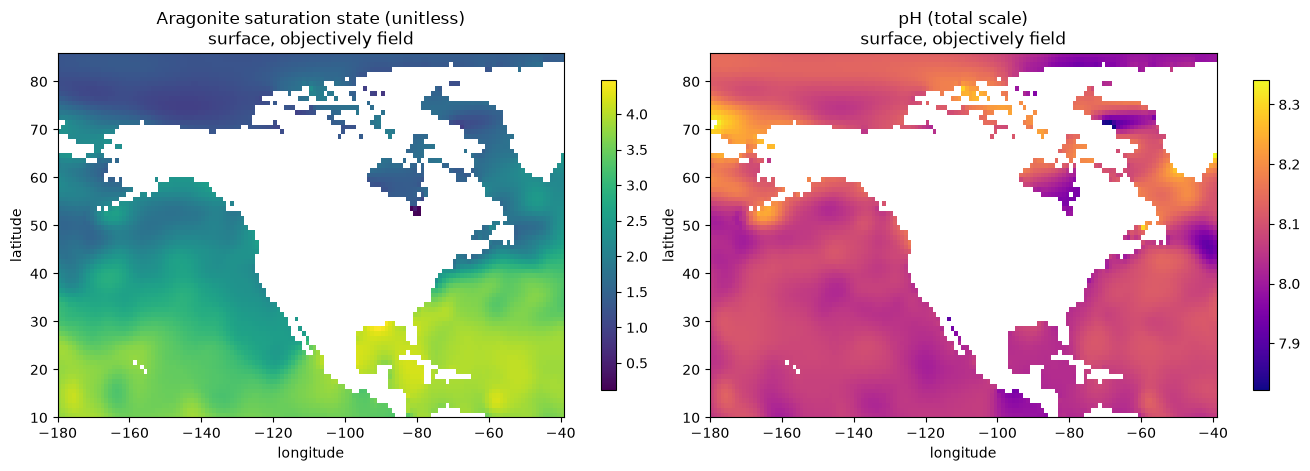

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)
for ax, (var, cmap, label) in zip(axes, [
        ('OmegaA_an', 'viridis', 'Aragonite saturation state (unitless)'),
        ('pHT_an', 'plasma', 'pH (total scale)')]):
    field = published[var].sel(depth=0)
    m = ax.pcolormesh(published.lon, published.lat, field, cmap=cmap, shading='auto')
    fig.colorbar(m, ax=ax, shrink=0.85)
    ax.set_title(f'{label}\nsurface, {published[var].attrs["long_name"].split()[0].lower()} field')
    ax.set_xlabel('longitude'); ax.set_ylabel('latitude')

covered = int(np.isfinite(published['OmegaA_an'].sel(depth=0)).sum())
print(f'surface OmegaA_an: {covered} of {76 * 141} grid cells have data '
      f'({100 * covered / (76 * 141):.0f}%)')
plt.show()

In [14]:
# A profile at one coastal point, and the observation counts behind it.
point = published.sel(lat=44.5, lon=-124.5, method='nearest')     # Oregon shelf
prof = point[['OmegaA_an', 'pHT_an', 'OmegaA_dd']].to_dataframe()[
    ['OmegaA_an', 'pHT_an', 'OmegaA_dd']]
print(f'profile at lat {float(point.lat):.1f}, lon {float(point.lon):.1f}')
print(prof.round(3).to_string())

profile at lat 44.5, lon -124.5
       OmegaA_an  pHT_an  OmegaA_dd
depth                              
0.0        2.404   8.110      107.0
10.0       2.295   8.087      110.0
20.0       2.031   8.041      110.0
30.0       1.777   7.998      102.0
50.0       1.457   7.929       84.0
75.0       1.163   7.826       67.0
100.0      0.959   7.734       46.0
125.0      0.836   7.687       40.0
150.0      0.820   7.679       36.0
200.0      0.726   7.636       19.0
250.0      0.729   7.642       27.0
300.0      0.678   7.616       17.0
400.0      0.598   7.573        9.0
500.0      0.567   7.558        3.0


## 10. Mirror the documentation to the store

Source Cooperative serves the repository's prefix as plain files, so the README, the
dependency floors, the credential helper and this notebook are uploaded beside the store.
A reader who finds the data on Source Cooperative then has everything needed to reproduce
it without going to GitHub.

Mirror **only from merged `main`** — uploading from a branch is how the published copies
drift out of step with the repository.

In [15]:
if RUN_MIRROR:
    import boto3
    from icechunk_utils import get_source_credentials

    creds, _exp = get_source_credentials()
    s3 = boto3.client(
        's3',
        endpoint_url=creds['endpoint_url'],
        aws_access_key_id=creds['aws_access_key_id'],
        aws_secret_access_key=creds['aws_secret_access_key'],
        aws_session_token=creds['aws_session_token'],
        region_name=creds['region_name'],
    )
    # '../' entries come from the repository root and land flattened on the
    # destination root, by file name.
    DOCS = ['README.md', 'requirements.txt',
            'oa-indicators-icechunk-sc.ipynb', '../icechunk_utils.py']
    for rel in DOCS:
        path = Path(rel)
        key = f'{DOCS_PREFIX}/{path.name}'
        ctype = {'.md': 'text/markdown; charset=utf-8',
                 '.txt': 'text/plain; charset=utf-8',
                 '.ipynb': 'application/x-ipynb+json',
                 '.py': 'text/x-python; charset=utf-8'}[path.suffix]
        s3.put_object(Bucket=SC_BUCKET, Key=key, Body=path.read_bytes(), ContentType=ctype)
        print(f'  uploaded {path.name:34s} -> {SC_BUCKET}/{key}')
else:
    print('RUN_MIRROR is False — nothing uploaded.')

RUN_MIRROR is False — nothing uploaded.
